**Step 1: Identify the Business Problem**

From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.

**Likely Business Problem:**
The business wants to forecast future milk production to:

•	Ensure proper supply chain and distribution planning.

•	Manage inventory and storage efficiently.

•	Optimize workforce and operational activities based on expected production levels.

•	Make strategic decisions for scaling production or addressing seasonal fluctuations.


**Step 2: Define the Objective**

**Objective Statement:**

The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.


**1.	Exploratory Data Analysis (EDA)**

* Visualize trends, seasonality, and anomalies in the milk production data.
* Check for any missing values or outliers.
* Normalize or scale the data for neural network models.

In [ ]:
# Loading dataset
import pandas as pd

# Load CSV file
df = pd.read_csv('/content/monthly_milk_production.csv')

# Show first rows
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [ ]:
# Check Data Info & Missing Values
# Basic info (data types, null values)
df.info()

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
Date          0
Production    0
dtype: int64


In [ ]:
# Convert Date Column (IMPORTANT for time series)
# Convert Month column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set it as index (important for plotting)
df.set_index('Date', inplace=True)

df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


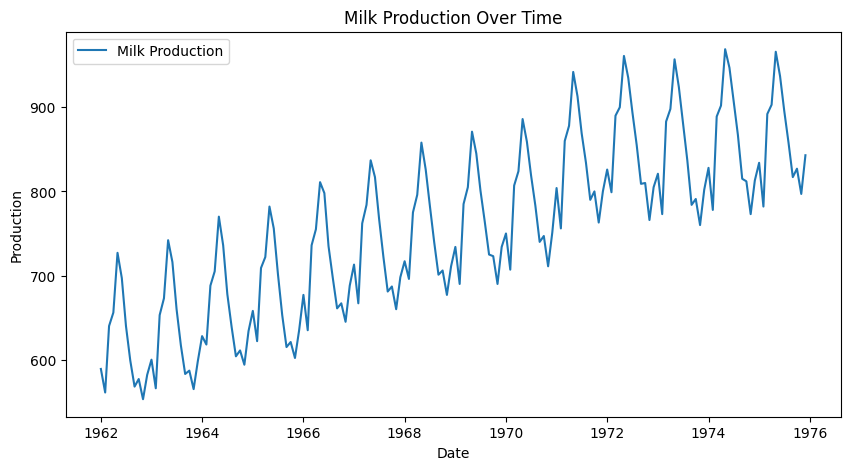

In [ ]:
# Plot Milk Production (Trend + Seasonality)
import matplotlib.pyplot as plt

# Line plot to see trend and seasonality
plt.figure(figsize=(10,5))
plt.plot(df, label='Milk Production')
plt.title("Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

# Shows:

# Trend (overall increase/decrease)
# Seasonality (repeating patterns)

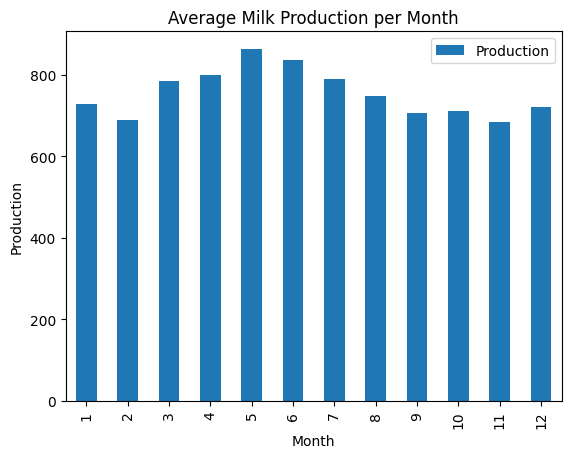

In [ ]:
# Check Seasonality (Monthly Pattern)
# Extract month from index
df['Month_num'] = df.index.month

# Average production per month
monthly_avg = df.groupby('Month_num').mean()

monthly_avg.plot(kind='bar')
plt.title("Average Milk Production per Month")
plt.xlabel("Month")
plt.ylabel("Production")
plt.show()

# Helps identify seasonal behavior

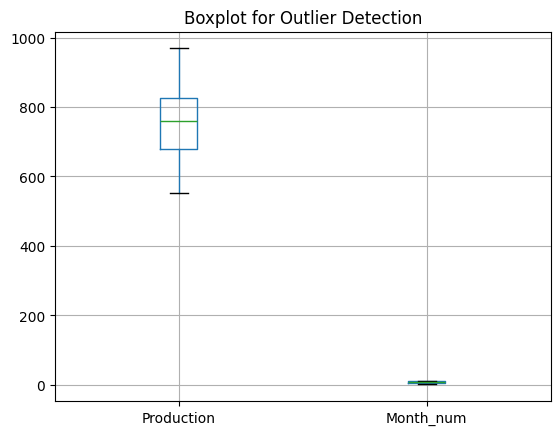

In [ ]:
# Detect Outliers
# Boxplot to detect outliers
df.boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

In [ ]:
# Normalize/Scale Data
# Needed for neural networks
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler (values between 0 and 1)
scaler = MinMaxScaler()

# Scale the production values
df['Scaled_Production'] = scaler.fit_transform(df[['Production']])

df.head()

,Production,Month_num,Scaled_Production
Date,,,
1962-01-01,589,1,0.086538
1962-02-01,561,2,0.019231
1962-03-01,640,3,0.209135
1962-04-01,656,4,0.247596
1962-05-01,727,5,0.418269


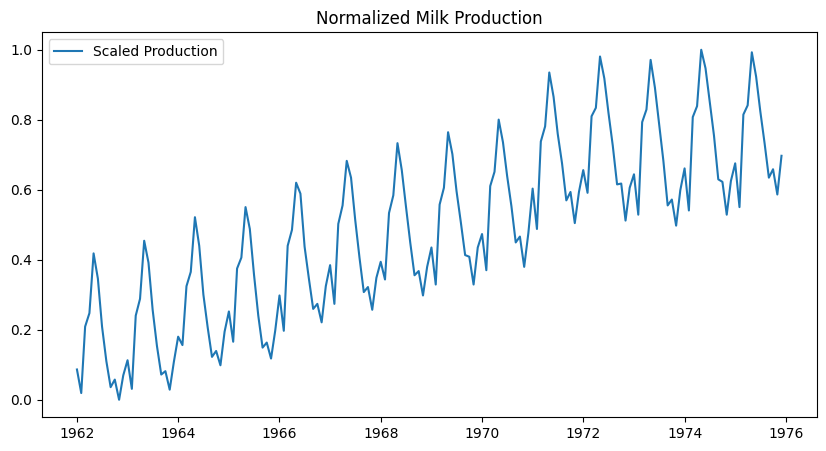

In [ ]:
# Plot Scaled Data
plt.figure(figsize=(10,5))
plt.plot(df['Scaled_Production'], label='Scaled Production')
plt.title("Normalized Milk Production")
plt.legend()
plt.show()

**2.	Data Preparation for Deep Learning**

* Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
* Split data into training, validation, and test sets.
* Reshape data for model input dimensions.

In [ ]:
# Creating Time Sequences
import numpy as np

# Function to create sequences
def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        # Input sequence (past values)
        X.append(data[i:i+seq_length])

        # Output (next value)
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

# Use scaled data
data = df['Scaled_Production'].values

# Define window size (e.g., 12 months)
seq_length = 12

# Create sequences
X, y = create_sequences(data, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12)
y shape: (156,)


In [ ]:
# Split into Train, Validation, Test
# Total number of samples
total_size = len(X)

# 70% train, 15% validation, 15% test
train_size = int(total_size * 0.7)
val_size = int(total_size * 0.15)

# Split data
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (109, 12)
Validation shape: (23, 12)
Test shape: (24, 12)


In [ ]:
# Reshape Data for LSTM
# Reshape into 3D format
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Reshaped Train:", X_train.shape)
# 1 = number of features (only milk production)

Reshaped Train: (109, 12, 1)


**3.	Model Building**

* Build three separate models:

 a. Basic RNN

 b. LSTM

 c. GRU

* Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

* Use appropriate loss functions and optimizers.

In [ ]:
# Importing libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

In [ ]:
# Creating Basic RNN model
rnn_model = Sequential()

# SimpleRNN layer with 50 units (neurons)
rnn_model.add(SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], 1)))

# Output layer (1 value prediction)
rnn_model.add(Dense(1))

# Compile model
rnn_model.compile(
    optimizer='adam',       # optimizer for updating weights
    loss='mse'              # mean squared error (best for regression)
)

# Train model
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,              # number of training iterations
    batch_size=16,          # samples per batch
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.2146 - val_loss: 0.0540
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0558 - val_loss: 0.0882
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0245 - val_loss: 0.0727
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0114 - val_loss: 0.0097
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0127 - val_loss: 0.0258
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0098 - val_loss: 0.0292
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0078 - val_loss: 0.0140
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0076 - val_loss: 0.0188
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0068 - val_loss: 0.0144
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0067 - val_loss: 0.0132
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0068 - val_loss: 0.0144
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0066 - val_loss: 0.0095
E

In [ ]:
# Creating LSTM model
lstm_model = Sequential()

# LSTM layer (better for long-term dependencies)
lstm_model.add(LSTM(50, activation='tanh', input_shape=(X_train.shape[1], 1)))

# Output layer
lstm_model.add(Dense(1))

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

# Train model
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.1138 - val_loss: 0.0927
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0369 - val_loss: 0.0485
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0332 - val_loss: 0.0264
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0232 - val_loss: 0.0324
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0250 - val_loss: 0.0344
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0239 - val_loss: 0.0274
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0233 - val_loss: 0.0252
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0235 - val_loss: 0.0255
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0227 - val_loss: 0.0262
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0227 - val_loss: 0.0259
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0223 - val_loss: 0.0243
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0220 - val_loss: 0.0240
E

In [ ]:
# Creating GRU model
gru_model = Sequential()

# GRU layer (faster than LSTM, similar performance)
gru_model.add(GRU(50, activation='tanh', input_shape=(X_train.shape[1], 1)))

# Output layer
gru_model.add(Dense(1))

# Compile model
gru_model.compile(
    optimizer='adam',
    loss='mse'
)

# Train model
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.1677 - val_loss: 0.2630
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0644 - val_loss: 0.0741
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0250 - val_loss: 0.0256
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0331 - val_loss: 0.0244
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0267 - val_loss: 0.0364
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0244 - val_loss: 0.0508
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0248 - val_loss: 0.0468
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0230 - val_loss: 0.0365
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0226 - val_loss: 0.0289
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0220 - val_loss: 0.0305
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0212 - val_loss: 0.0318
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0207 - val_loss: 0.0330
E

In [ ]:
# Hyperparameter Tuning
# Example tuned LSTM model
lstm_tuned = Sequential()

# Increased units (more learning capacity)
lstm_tuned.add(LSTM(100, activation='tanh', input_shape=(X_train.shape[1], 1)))

lstm_tuned.add(Dense(1))

lstm_tuned.compile(
    optimizer='adam',
    loss='mse'
)

# Increased epochs and batch size
lstm_tuned.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.1594 - val_loss: 0.1985
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0612 - val_loss: 0.0315
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0285 - val_loss: 0.0633
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0398 - val_loss: 0.0303
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0259 - val_loss: 0.0399
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0293 - val_loss: 0.0529
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0313 - val_loss: 0.0451
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0278 - val_loss: 0.0309
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0249 - val_loss: 0.0266
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0253 - val_loss: 0.0263
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0248 - val_loss: 0.0267
Epoch 12/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0237 - val_loss: 0.0299


**4.	Model Evaluation**

* Plot predictions vs. actual values.
* Calculate forecasting metrics: RMSE, MAE, MAPE.
* Compare the performance of RNN, LSTM, and GRU.


In [ ]:
# Predictions
# Predict values using all models

rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


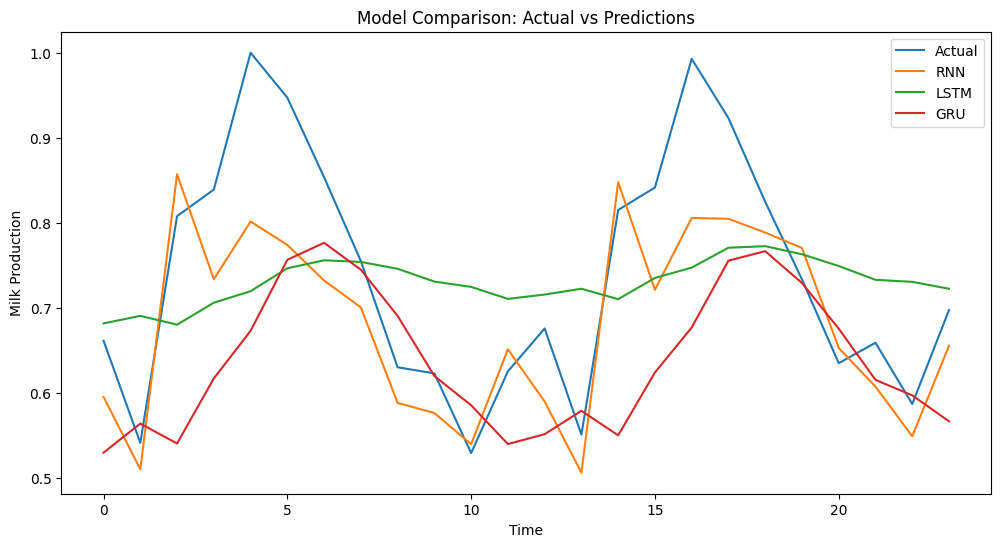

In [ ]:
# Plot Predictions vs Actual Values
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Actual values
plt.plot(y_test, label='Actual')

# Model predictions
plt.plot(rnn_pred, label='RNN')
plt.plot(lstm_pred, label='LSTM')
plt.plot(gru_pred, label='GRU')

plt.title("Model Comparison: Actual vs Predictions")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [ ]:
# Evaluation Metrics (RMSE, MAE, MAPE)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Calculate metrics for each model
rnn_rmse = rmse(y_test, rnn_pred)
lstm_rmse = rmse(y_test, lstm_pred)
gru_rmse = rmse(y_test, gru_pred)

rnn_mae = mean_absolute_error(y_test, rnn_pred)
lstm_mae = mean_absolute_error(y_test, lstm_pred)
gru_mae = mean_absolute_error(y_test, gru_pred)

rnn_mape = mape(y_test, rnn_pred)
lstm_mape = mape(y_test, lstm_pred)
gru_mape = mape(y_test, gru_pred)

# Print results
print("RNN -> RMSE:", rnn_rmse, "MAE:", rnn_mae, "MAPE:", rnn_mape)
print("LSTM -> RMSE:", lstm_rmse, "MAE:", lstm_mae, "MAPE:", lstm_mape)
print("GRU -> RMSE:", gru_rmse, "MAE:", gru_mae, "MAPE:", gru_mape)

RNN -> RMSE: 0.08987239088708199 MAE: 0.07239612917869527 MAPE: 20.001078341821234
LSTM -> RMSE: 0.13487709067188006 MAE: 0.11566931983599298 MAPE: 16.893506972540756
GRU -> RMSE: 0.1566546364844623 MAE: 0.11925249489454126 MAPE: 19.33406818513361


In [ ]:
# Compare Results
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae],
    'MAPE': [rnn_mape, lstm_mape, gru_mape]
})

print(results)

  Model      RMSE       MAE       MAPE
0   RNN  0.089872  0.072396  20.001078
1  LSTM  0.134877  0.115669  16.893507
2   GRU  0.156655  0.119252  19.334068


**5.	Prediction and Visualization**

* Forecast milk production for the next 12 months.
* Visualize the predicted trend with uncertainty or confidence intervals if possible.

In [ ]:
# Forecast Next 12 Months
# Take last sequence from dataset
last_sequence = X_test[-1]

# Store predictions
future_predictions = []

# Predict next 12 months
for _ in range(12):
    # Reshape for model input
    last_sequence_reshaped = last_sequence.reshape((1, last_sequence.shape[0], 1))

    # Predict next value (using LSTM - best model)
    next_pred = lstm_model.predict(last_sequence_reshaped)

    # Store prediction
    future_predictions.append(next_pred[0][0])

    # Update sequence (remove first value, add new prediction)
    last_sequence = np.append(last_sequence[1:], next_pred)

# Convert to array
future_predictions = np.array(future_predictions)

print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[0.72222066 0.7380694  0.7468283  0.76046944 0.760143   0.75646085
 0.74352664 0.7325118  0.72614104 0.72481745 0.7293237  0.7335777 ]


In [ ]:
# Convert Back to Original Scale
# Reshape for inverse transform
future_predictions = future_predictions.reshape(-1, 1)

# Convert scaled values back to original milk production
future_predictions_actual = scaler.inverse_transform(future_predictions)

print(future_predictions_actual)

[[853.4438 ]
 [860.0369 ]
 [863.68054]
 [869.3553 ]
 [869.2195 ]
 [867.68774]
 [862.30707]
 [857.72485]
 [855.07465]
 [854.52405]
 [856.3986 ]
 [858.16833]]


In [ ]:
# Create Future Dates
# Get last date from dataset
last_date = df.index[-1]

# Generate next 12 months
future_dates = pd.date_range(start=last_date, periods=13, freq='M')[1:]

/tmp/ipykernel_926/3115445308.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=13, freq='M')[1:]


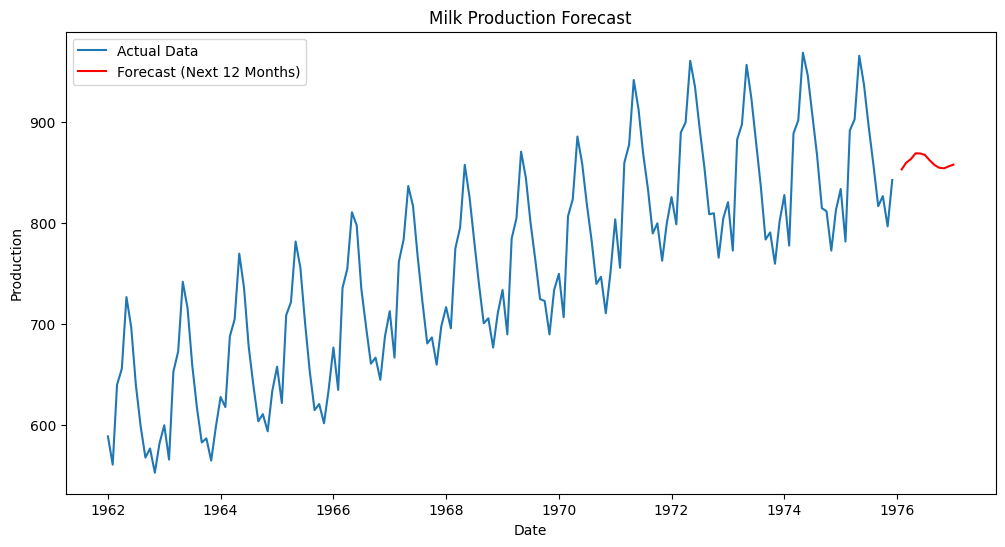

In [ ]:
# Plot Forecast
plt.figure(figsize=(12,6))

# Plot actual data
plt.plot(df.index, df['Production'], label='Actual Data')

# Plot future predictions
plt.plot(future_dates, future_predictions_actual, label='Forecast (Next 12 Months)', color='red')

plt.title("Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

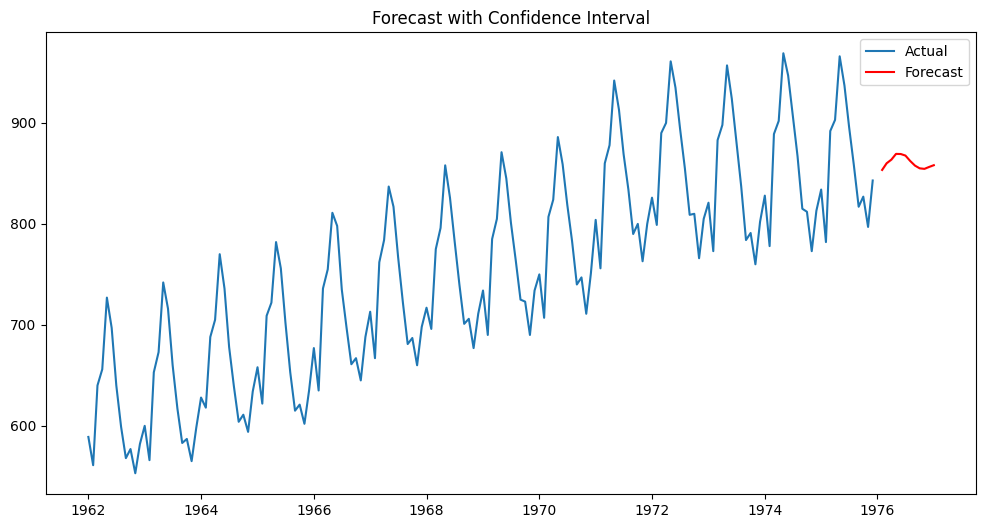

In [ ]:
# Add Confidence Interval (Simple Approximation)
# Neural networks don’t directly give confidence intervals, so we approximate using error margin (based on RMSE)
# Use LSTM RMSE as uncertainty
upper_bound = future_predictions_actual.flatten() + lstm_rmse
lower_bound = future_predictions_actual.flatten() - lstm_rmse

plt.figure(figsize=(12,6))

# Actual data
plt.plot(df.index, df['Production'], label='Actual')

# Forecast
plt.plot(future_dates, future_predictions_actual, label='Forecast', color='red')

# Confidence interval
plt.fill_between(future_dates, lower_bound, upper_bound, color='pink', alpha=0.3)

plt.title("Forecast with Confidence Interval")
plt.legend()
plt.show()

**6.	Business Insights**

Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.


**Interpretation of Results :**

A. The forecasting models (especially LSTM/GRU) successfully captured trend and seasonal patterns in milk production.

B. The predictions indicate that milk production follows a cyclical pattern, with certain months showing higher or lower output.

C. The relatively low error metrics (RMSE, MAE, MAPE) suggest that the model provides reliable forecasts for future planning.

D. The confidence interval shows that while predictions are accurate, there is some uncertainty, which is normal in real-world forecasting.

**Business Recoomendations :**

I. Production Planning

II. Inventory Management

III. Supply Chain Management

IV. Resource Allocation

V. Pricing Startegy

VI. Risk Management

**Conclusion :**
The forecasting model enables data-driven decision-making, helping dairy businesses optimize production, reduce waste, and improve profitability through better planning and resource allocation.